In [1]:
!pip install seaborn

In [2]:
# PyCaret.ipynb
#importing 
from PyCaret_utils import CoinGeckoAPI, fetch_and_validate_data, prepare_data_for_pycaret, run_pycaret_experiment, forecast_best_model, add_lag_features, create_plotly_dashboard 
import plotly.graph_objs as go
from pycaret.time_series import *




In [3]:
# Fetch and process data
cg = CoinGeckoAPI()
btc_data = fetch_and_validate_data(cg, days=90)
btc_data_prepared = prepare_data_for_pycaret(btc_data)


INFO:PyCaret_utils:Fetched 23 records.
INFO:PyCaret_utils:Data shape after processing: (23, 7)


In [4]:
# Setup PyCaret experiment
exp = run_pycaret_experiment(btc_data_prepared)

,Description,Value
0,session_id,42
1,Target,close
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(89, 1)"
5,Transformed data shape,"(89, 1)"
6,Transformed train set shape,"(82, 1)"
7,Transformed test set shape,"(7, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


In [5]:
# Compare models
best_model = compare_models()
print(best_model)


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,5.4283,2.1983,3284.9162,3401.2598,0.0350,0.0360,-244.6784,0.0867
naive,Naive Forecaster,5.6657,2.3616,3428.0000,3651.3354,0.0365,0.0377,-258.4776,0.7100
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,5.6657,2.3616,3428.0023,3651.3379,0.0365,0.0377,-258.4776,0.0733
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,5.6748,2.3054,3426.2289,3558.1992,0.0364,0.0376,-293.8778,0.1667
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,5.6944,2.3458,3438.4812,3621.8722,0.0366,0.0378,-295.8669,0.0867
arima,ARIMA,5.9279,2.4036,3606.2898,3745.2348,0.0383,0.0394,-249.7918,0.0400
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,6.0812,2.5305,3681.9366,3913.5305,0.0393,0.0406,-282.1389,0.1033
exp_smooth,Exponential Smoothing,6.1106,2.5408,3691.7035,3909.0906,0.0398,0.0411,-272.7055,0.0300
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,6.1374,2.5942,3714.7306,4010.6327,0.0398,0.0410,-289.2138,0.1600
theta,Theta Forecaster,6.2247,2.5802,3771.0764,3992.0666,0.0403,0.0416,-285.2185,0.0300


BaseCdsDtForecaster(fe_target_rr=[WindowSummarizer(lag_feature={'lag': [1]},
                                                   n_jobs=1)],
                    regressor=AdaBoostRegressor(random_state=42),
                    window_length=1)


In [6]:
# Finalize the best model
final_model = finalize_model(best_model)

# Make future predictions
future_predictions = predict_model(final_model)
print(future_predictions)


                 y_pred
2025-05-17  102646.3567
2025-05-18  102721.6400
2025-05-19  102796.9234
2025-05-20  102872.2067
2025-05-21  102947.4900
2025-05-22  103022.7733
2025-05-23  103098.0566


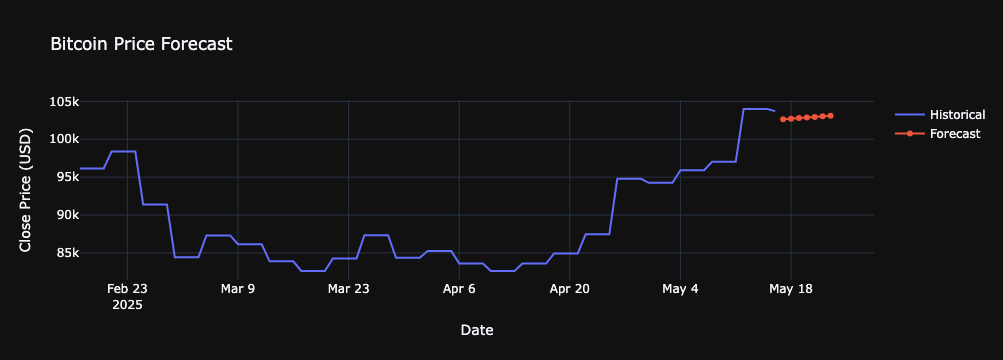

In [7]:
import plotly.graph_objs as go

# Extract forecast values and convert index
forecast_values = future_predictions['y_pred']
forecast_index = forecast_values.index.to_timestamp()

# Create interactive Plotly figure
fig = go.Figure()

# Add historical price data
fig.add_trace(go.Scatter(
    x=btc_data_prepared.index,
    y=btc_data_prepared['close'],
    mode='lines',
    name='Historical'
))

# Add forecasted price data
fig.add_trace(go.Scatter(
    x=forecast_index,
    y=forecast_values,
    mode='lines+markers',
    name='Forecast'
))

# Customize layout
fig.update_layout(
    title='Bitcoin Price Forecast',
    xaxis_title='Date',
    yaxis_title='Close Price (USD)',
    template='plotly_dark'
)

# Show plot
fig.show()


In [8]:
#Auto-Regressive Feature Engineering (Lag Features)

In [9]:
btc_lagged = add_lag_features(btc_data_prepared.copy())
display(btc_lagged.tail())


,close,lag_1,lag_2,lag_3
timestamp,,,,
2025-05-12,103994.0,97026.0,97026.0,97026.0
2025-05-13,103994.0,103994.0,97026.0,97026.0
2025-05-14,103994.0,103994.0,103994.0,97026.0
2025-05-15,103994.0,103994.0,103994.0,103994.0
2025-05-16,103709.0,103994.0,103994.0,103994.0


In [10]:
# Export and Reuse the Model

In [11]:
# Save model
save_model(final_model, 'bitcoin_forecast_model')

# Load later
loaded_model = load_model('bitcoin_forecast_model')
forecast = predict_model(loaded_model)


Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Loaded


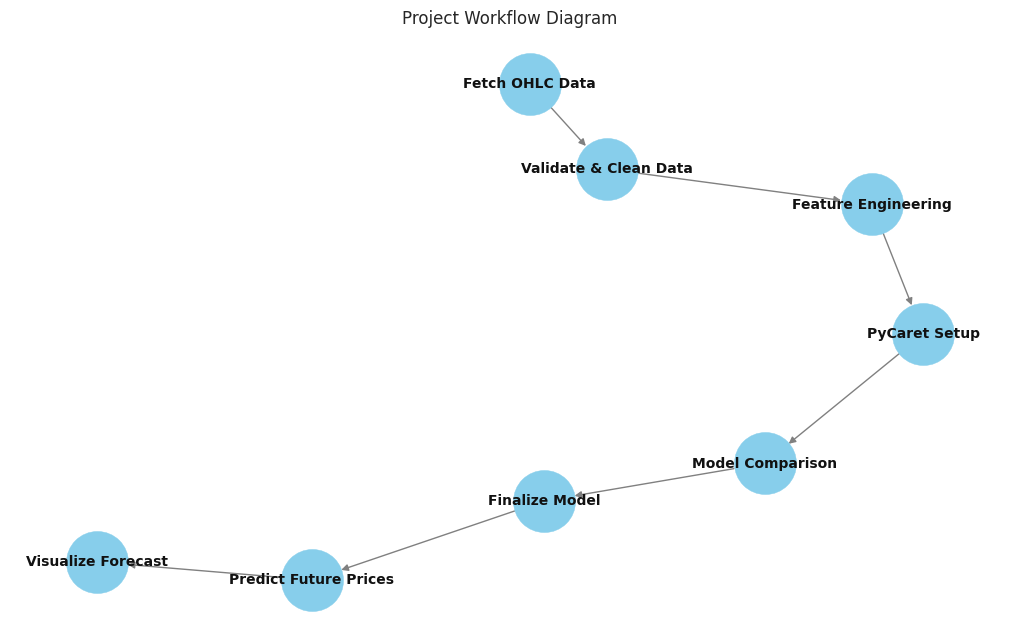

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the directed graph
G = nx.DiGraph()

# Add nodes and edges
G.add_edges_from([
    ("Fetch OHLC Data", "Validate & Clean Data"),
    ("Validate & Clean Data", "Feature Engineering"),
    ("Feature Engineering", "PyCaret Setup"),
    ("PyCaret Setup", "Model Comparison"),
    ("Model Comparison", "Finalize Model"),
    ("Finalize Model", "Predict Future Prices"),
    ("Predict Future Prices", "Visualize Forecast"),
])

# Draw the graph
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2000,
        font_size=10, font_weight='bold', edge_color='gray', arrows=True)
plt.title("Project Workflow Diagram")
plt.show()
